In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from enum import StrEnum
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

In [2]:
FILE_PATH: str = "~/Data/Eranaeos/pump_sensor/pump_sensor.csv"  # local file
NAN_LIMIT_PERCENT: float = 3.0  # a sensor with more than this NaNs will be removed
PCA_PRESERVATION: float = 0.75  # how much information is preserved after PCA
TRAINING_RATE: float = 0.8  # how much data is used for the training of the models
GMM_COMPONENTS: int = 4  # how many modes for a GMM

In [3]:
class Status(StrEnum):
    BROKEN: str = "BROKEN"  # label broken
    NORMAL: str = "NORMAL"  # label normal
    RECOVERING: str = "RECOVERING"  # label recovering

colors = {
    Status.NORMAL: "green",
    Status.BROKEN: "red",
    Status.RECOVERING: "yellow"
}

In [4]:
raw_data: pd.DataFrame = pd.read_csv(FILE_PATH, index_col=0)
raw_data["timestamp"] = pd.to_datetime(raw_data["timestamp"])
raw_data.head()

,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [5]:
# find out whether the case is rather a multi class or single class problem

n_normal: int = sum(raw_data["machine_status"] == Status.NORMAL)
n_broken: int = sum(raw_data["machine_status"] == Status.BROKEN)
n_recovering: int = sum(raw_data["machine_status"] == Status.RECOVERING)
n_samples: int = len(raw_data)

print(f"Normal: {n_normal} ({100.0*float(n_normal)/n_samples:.2f})%\n"
      f"Broken: {n_broken} ({100.0*float(n_broken)/n_samples:.2f}%)\n"
      f"Recovering: {n_recovering} ({100.0*float(n_recovering)/n_samples:.2f}%)")

Normal: 205836 (93.43)%
Broken: 7 (0.00%)
Recovering: 14477 (6.57%)


In [6]:
# dealing with NaNs, Infs, ...
invalid_sum: pd.Series = (raw_data.isna() | raw_data.isin([np.inf, -np.inf])).sum()
all_sensors = [f"sensor_{i:02d}" for i in range(0, 52)]
limit_number = NAN_LIMIT_PERCENT / 100.0 * n_samples
bad_sensors = {
    sensor: f"{float(invalid_sum[sensor]) / n_samples * 100.0:.2f}%"
    for sensor in all_sensors
    if float(invalid_sum[sensor]) > limit_number
}
sensors = [sensor for sensor in all_sensors if sensor not in bad_sensors.keys()]

raw_data.replace([np.inf, -np.inf], np.nan, inplace=True)
raw_data[sensors] = raw_data[sensors].ffill()  # only good data in the good sensors

print(bad_sensors)

{'sensor_00': '4.63%', 'sensor_15': '100.00%', 'sensor_50': '34.96%', 'sensor_51': '6.98%'}


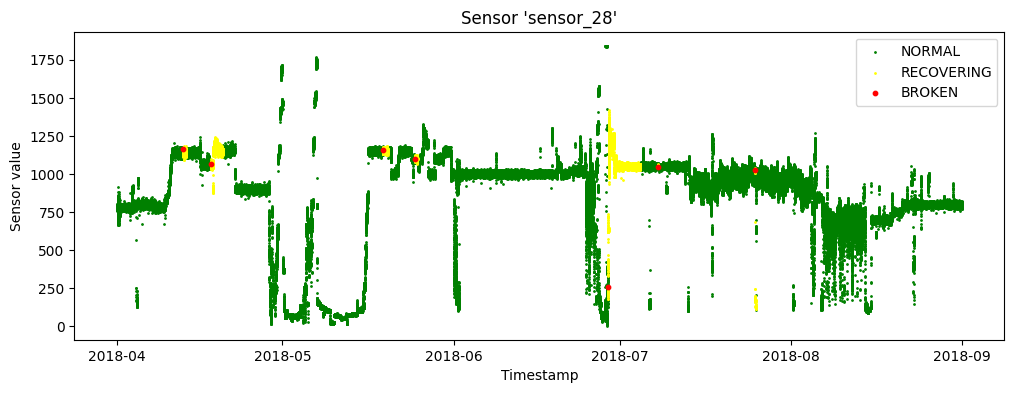

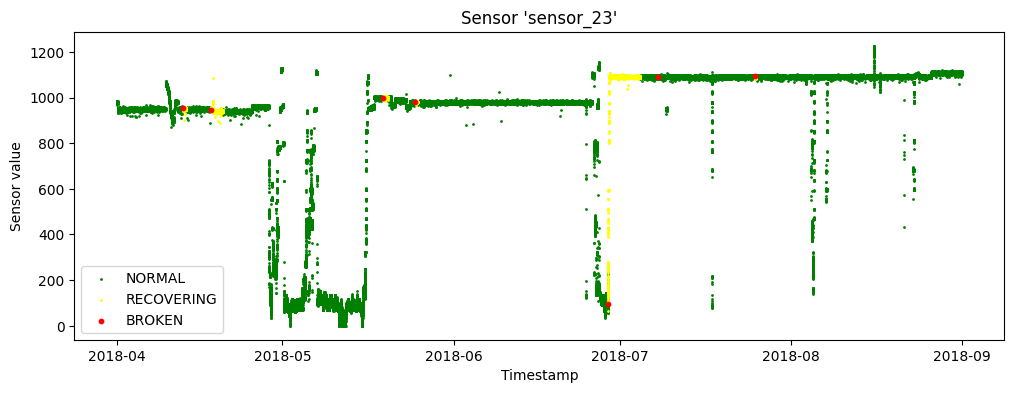

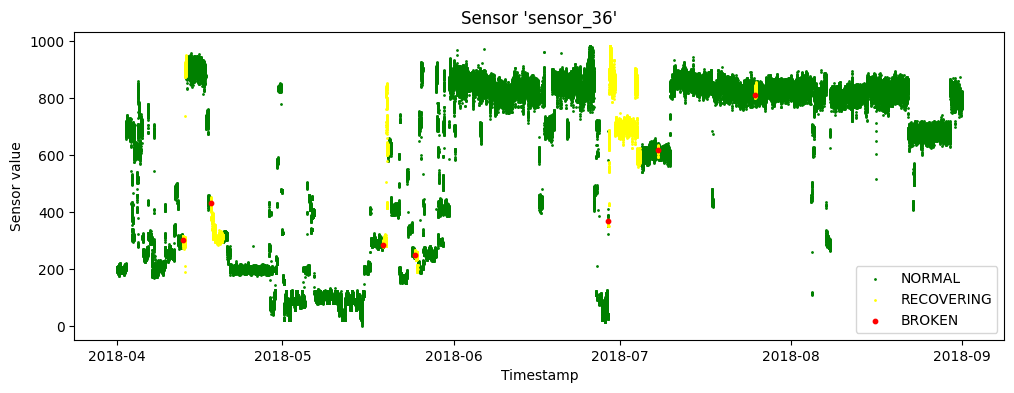

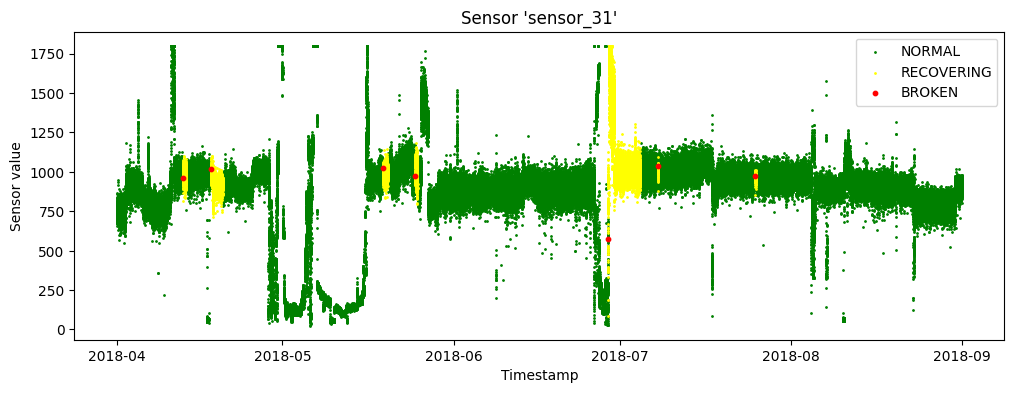

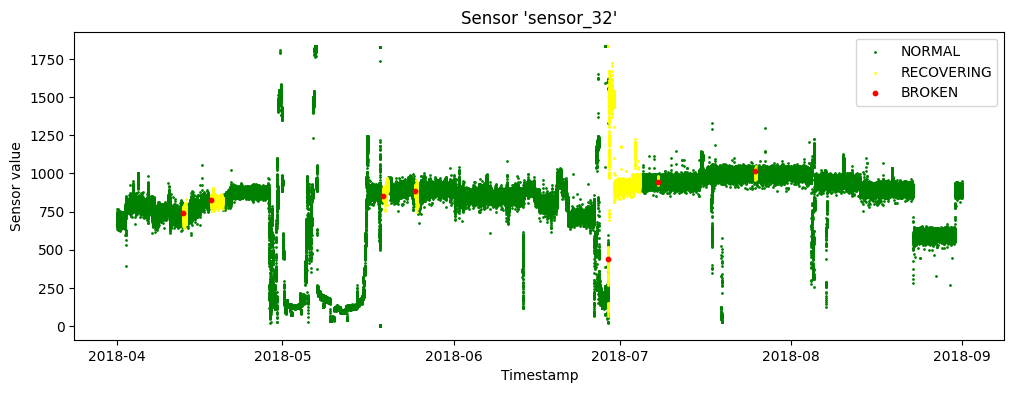

In [7]:
# now we know which sensors are okay, let's plot some good ones with high variation
high_var_sensors = sorted(sensors, key=lambda sensor: raw_data[sensor].var(), reverse=True)[:5]

for sensor in high_var_sensors:
    plt.figure(figsize=(12, 4))
    for status in [Status.NORMAL, Status.RECOVERING, Status.BROKEN]:
        df_now = raw_data.loc[raw_data["machine_status"] == status, ["timestamp", sensor]]
        marker_size = 10 if status == Status.BROKEN else 1
        plt.scatter(df_now["timestamp"], df_now[sensor], color=colors[status], s=marker_size, label=status)
    plt.title(f"Sensor '{sensor}'")
    plt.xlabel("Timestamp")
    plt.ylabel("Sensor value")
    plt.legend()
    plt.show()

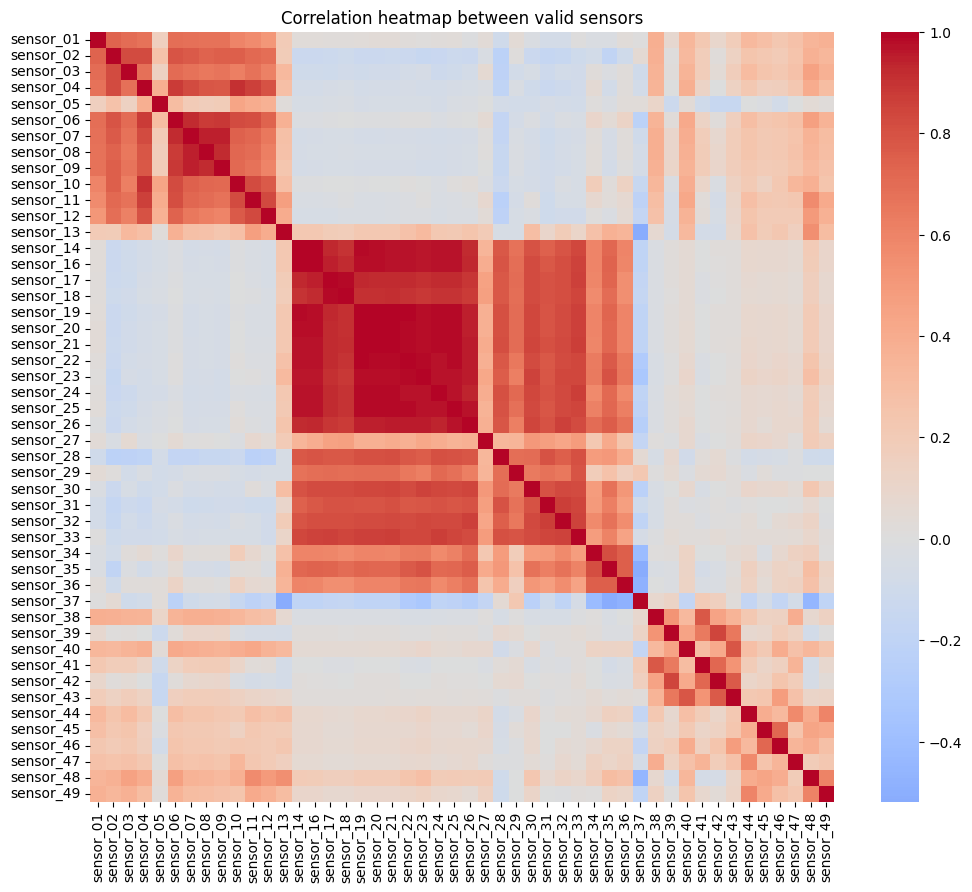

In [8]:
# now we look at the correlation between the sensors

corr = raw_data[sensors].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap between valid sensors")
plt.show()

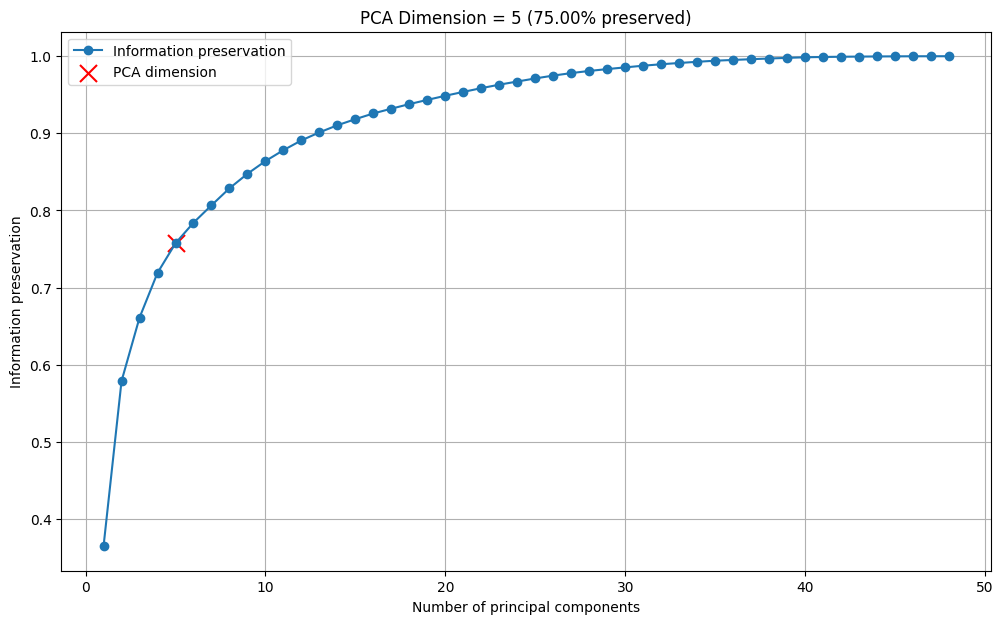

In [9]:
# Perform a PCA

X = raw_data[sensors]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca_full = PCA(n_components=None)
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
pca_dim = next((x + 1 for x in range(0, len(cumulative_variance))
                if cumulative_variance[x] >= PCA_PRESERVATION))
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', label="Information preservation")
plt.scatter(pca_dim, cumulative_variance[pca_dim - 1], marker='x', s=150, c="red", label="PCA dimension")
plt.xlabel("Number of principal components")
plt.ylabel("Information preservation")
plt.legend()
plt.grid(True)
plt.title(f"PCA Dimension = {pca_dim} ({PCA_PRESERVATION*100:.2f}% preserved)")
plt.show()

In [10]:
pca = PCA(n_components=pca_dim)
X_transformed = pca.fit_transform(X_scaled)
pca_labels = [f"PC{i+1:02d}" for i in range(0, X_transformed.shape[1])]

df = pd.DataFrame(X_transformed, columns=pca_labels)
df["timestamp"] = raw_data["timestamp"].values
df["machine_status"] = raw_data["machine_status"].values
df = df.set_index("timestamp")
train_limit: pd.Timestamp = df.index.min() + TRAINING_RATE * (df.index.max() - df.index.min())
df.head()

,PC01,PC02,PC03,PC04,PC05,machine_status
timestamp,,,,,,
2018-04-01 00:00:00,0.034081,0.545866,-0.589812,0.684500,2.297012,NORMAL
2018-04-01 00:01:00,0.034081,0.545866,-0.589812,0.684500,2.297012,NORMAL
2018-04-01 00:02:00,0.173676,0.582550,-0.596341,0.778801,2.408031,NORMAL
2018-04-01 00:03:00,0.173411,0.597803,-0.600880,0.886619,2.396257,NORMAL
2018-04-01 00:04:00,0.127427,0.714334,-0.483850,0.917249,2.322166,NORMAL


In [11]:
# data generator
def data_generator(data_frame: pd.DataFrame,
                   dt: float = 60.0,
                   sequence_length: int = 30,
                   batch_size: int = 32):
    start_time = data_frame.index.min()
    end_time = data_frame.index.max()
    time_delta = pd.Timedelta(seconds=dt*sequence_length)
    batch = []
    while start_time + time_delta < end_time:
        current_sequence = data_frame.loc[start_time <= data_frame.index
                                          < start_time + time_delta]
        target_index = pd.date_range(
            start=start_time,
            periods=sequence_length,
            freq=pd.Timedelta(seconds=dt)
        )
        seq = current_sequence.reindex(target_index).interpolate(
            method="time",
            limit_direction="both"
        )
        batch.append(seq.values)
        if len(batch) == batch_size:
            yield np.stack(batch, axis=0)
            batch = []
        start_time += pd.Timedelta(seconds=dt)

In [12]:
normal_data: pd.DataFrame = df.loc[df["machine_status"] == Status.NORMAL]
training_data: pd.DataFrame = normal_data.loc[normal_data.index <= train_limit, pca_labels]
test_data: pd.DataFrame = normal_data.loc[train_limit < normal_data.index, pca_labels]

In [13]:
# GMM doesn't need a generator because each sample is learned individually
gmm = GaussianMixture(n_components=GMM_COMPONENTS, covariance_type='full', random_state=42)
gmm.fit(training_data)

,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42
